In [17]:
!pip install qiskit qiskit-aer qiskit[visualization] qiskit-ibm-runtime dotenv

In [18]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from itertools import islice

In [19]:
# Initializing the backend
from dotenv import load_dotenv
import os

load_dotenv()
token = os.getenv("QISKIT_API_KEY")

try:
    QiskitRuntimeService.save_account(
        token=token
    )
except Exception as e:
    print(f"Error saving account: {e}")

service = QiskitRuntimeService()

# https://quantum.cloud.ibm.com/docs/en/guides/hello-world
# https://cloud.ibm.com/iam/apikeys?bss_account=952fc7dad0544862a921fee4630e8563

Error saving account: 'Named account (default-ibm-quantum-platform) already exists. Set overwrite=True to overwrite.'


qiskit_runtime_service.__init__:WARNING:2026-03-18 10:37:39,582: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [20]:
# Fake
'''
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()
'''

'\nfrom qiskit.primitives import StatevectorSampler\nsampler = StatevectorSampler()\n'

In [21]:
# Real
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Select a real backend
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(backend)


qiskit_runtime_service.backends:WARNING:2026-03-18 10:37:40,299: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-18 10:37:43,471: Using instance: open-instance, plan: open


In [22]:
# Initialize quantum circuit with one qubit and one classical bit
circ = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit at the index 0
circ.h(0)

# Measure the qubit at index 0 and store in the classical bit at index 0
circ.measure(0,0)

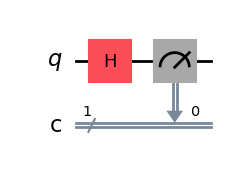

In [23]:
# Draw the quantum circuit using matplotlib
circ.draw("mpl")

In [24]:
print("Details of Classical Register: ", circ.cregs)
# Details of Classical Register:  [ClassicalRegister(1, 'c')]

print("Details of Quantum Register: ", circ.qregs)
# Details of Quantum Register:  [QuantumRegister(1, 'q')]

Details of Classical Register:  [ClassicalRegister(1, 'c')]
Details of Quantum Register:  [QuantumRegister(1, 'q')]


In [25]:
# Transpile 
circ = transpile(circ, backend)

In [26]:
BITS = 32
NUMBERS = 10000

In [27]:
# Run the simulator 640000 times to generate 1000 64-bit number
job = sampler.run([(circ,None, BITS*NUMBERS)])
result = job.result()
# Extract the results from memory in a list and print them
print(result[0].data)
memory = result[0].data.c.get_bitstrings()
# print(memory)

DataBin(c=BitArray(<shape=(), num_shots=320000, num_bits=1>))


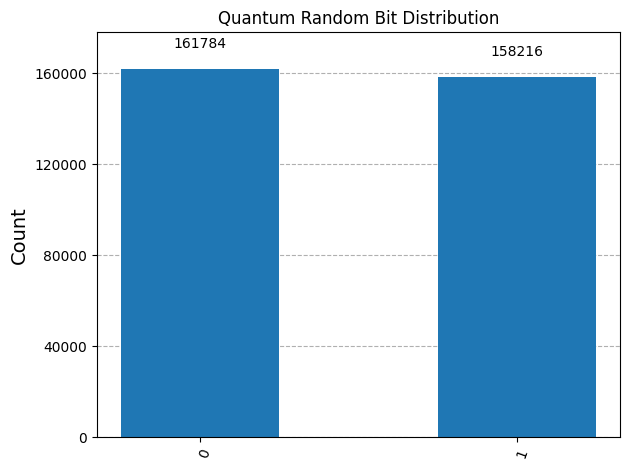

In [28]:
# Get the data of our experiment
counts = result[0].data.c.get_counts()

# Plot the data in a histogram
plot_histogram(counts, title='Quantum Random Bit Distribution')

In [29]:
def save_binary_list_to_file(memory_list, filename='output.bin'):
    """
    Convert a list of binary strings ('0', '1') into a binary file.
    Groups bits into 8-bit bytes and writes them as binary data.
    """
    # Join all bits into a single string
    binary_string = ''.join(memory_list)
    
    # Pad with zeros on the right if not divisible by 8
    padding = (8 - len(binary_string) % 8) % 8
    binary_string += '0' * padding
    
    # Convert each 8-bit chunk to a byte and write to file
    with open(filename, 'wb') as f:
        for i in range(0, len(binary_string), 8):
            byte_string = binary_string[i:i+8]
            byte_value = int(byte_string, 2)  # Convert binary string to integer
            f.write(bytes([byte_value]))
    
    print(f"Written {len(binary_string) // 8} bytes to {filename}")


In [30]:
save_binary_list_to_file(memory, 'real5.bin')

Written 40000 bytes to real5.bin
